In [6]:
import numpy as np
import pandas as pd
import altair as alt
import statsmodels.api as sm
from scipy import linalg
from statsmodels.multivariate.pca import PCA

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

alt.data_transformers.disable_max_rows()
alt.renderers.enable('default')

RendererRegistry.enable('default')

In [7]:
fertility = pd.read_csv('data/fertility.csv')
country = pd.read_csv('data/country-indicators.csv')
gender = pd.read_csv('data/gender-data.csv')

# Analysis of Fertility Rates
Alice Zhang 

## Abstract
My project examines the decline in fertility rates across select developed nations in 2018 and seeks to quantify the impact of gender, country, and world development indicators to total fertility rates. To achieve this, I will be conducting an in-depth analysis of fertility data in Python, applying various data science techniques to address my research questions.  

Given the relatively small dataset, which includes only a subset of available indicators, the findings are not generalizable to all countries. Additionally, since the data pertains only to the year 2018, the results do not capture potential trends or patterns over time. The analysis may also be subject to biases due to missing data, and we acknowledge that not all potential confounding factors can be accounted for in this study.


## Introduction

### Background


Over the late 50 years, the global fertility rate has halved. Modernization and technological advancements were coupled with a stark decline in fertility rates and accelerated population growth, which was expected to come to an end as total fertility rates – measured as the average number of children per woman – continue to fall. As of 2021, the global fertility rate is 1.66 and [falling](https://www.cbo.gov/publication/58912#:~:text=In%20CBO's%20projections%2C%20the%20total,where%20it%20remains%20through%202053). 


[Current perspectives](https://ourworldindata.org/fertility-rate#data-sources)  attribute this decline to factors such as women’s social mobility, economic stability, and improvements in child well-being. This project seeks to answer the following questions:
* Which factors most predict a country’s fertility rate?
* How do upward mobility, economic prosperity, and child well-being impact fertility rates?
* Which of these explanations are the most probable?

### Sources
The data used in this project are sourced from
* [United Nations Development Programme](https://www.undp.org/) 
* [World Bank](https://data.worldbank.org/)
* Preprocessed datasets from [lab06](https://github.com/ucsb-ds/pstat100-content/tree/main/labs/lab6-regression/data). 

### Motivation

From an economic standpoint, improved welfare is expected to *increase* fertility rates. Modernization has largely enhanced reproductive success by improving access to resources like immunizations, which help reduce mortality. The pre-modern era, characterized by high mortality rates and widespread disease, had higher fertility rates than today. Was fertility simply a matter of scarcity? Or could it be that reproduction was viewed as more desirable in the past due to limited opportunities for women?

Modern research also explores the impact of social mobility and status enhancement on fertility. As modernization progresses, women are becoming more career-oriented, narrowing the wage gap and breaking through the glass ceiling. Does upward social mobility, along with shifts in social conventions, lead women to reject traditional gender roles such as childbearing?

By examining these socio-economic factors, this project aims to contribute to a deeper understanding of how modernization, economic prosperity, and gender roles shape fertility trends in the 21st century.

### Data Description

This project utilizes datasets that measure human development, gender development, and world development indices across various countries. The datasets were created by merging data from the Human Development Index (HDI), Gender Development Index (GDI), and World Development Index (WDI), with a focus on indicators relevant to fertility rate analysis.

We specifically examine the following variables:
* GDP per capita: The total economic output of a country, adjusted for population size, and measured in current U.S. dollars.
* Immunization rate: The percentage of children aged 12-23 months who have received DPT (diphtheria, pertussis, and tetanus) and measles vaccinations.
* Life expectancy at birth: An indicator of health that reflects the average number of years a newborn is expected to live, assuming age-specific mortality rates remain constant.
* Expected years of schooling: The total number of years of schooling that a child of school-entry age can expect to receive, assuming age-specific enrollment ratios remain unchanged.
* HDI (Human Development Index): A composite index measuring a country's achievements in three key dimensions of human development: health (life expectancy), education (mean and expected years of schooling), and standard of living (GNI per capita).
* GDI (Gender Development Index): An index measuring gender inequalities in human development, considering health, education, and economic resources (such as earned income).

The HDI is calculated as the geometric mean of normalized indices for each of these three dimensions, while the GDI adjusts for gender inequalities within these areas. Detailed technical notes on the calculation of these indices can be found [here](https://hdr.undp.org/system/files/documents/technical-notes-calculating-human-development-indices.pdf). 

**Data on social mobility** is partially represented through education level, which serves as a proxy for career opportunities and social status. Education correlates strongly with economic mobility and can indicate access to better jobs and career stability. Although unemployment data is also a potential indicator of social mobility, it was excluded due to high levels of missing data.

**Sampling design and methods**: The datasets used in this analysis are sourced from reputable organizations, including the United Nations Development Programme (UNDP) and the World Bank. While the sampling methods and data sources are assumed to be reliable, some limitations exist. For example, data reporting errors and translation inaccuracies may occur when normalizing data to a consistent unit of measurement. These issues could affect the representativeness of the variables included in the analysis.

#### Variable Description

The variables we'll be exploring include: 

Dataset | Name | Variable | Units
---|---|---|---
`fertility` | `fertility_total` | National fertility rate | Average number of children per woman
`country` | `gdp_percap` | GDP per capita | current U.S. dollars
`country` | `immunization` | Average immunization rate| Percentage (value 1-100)
`country` | `gdi` | Gender development index | Index between 0 and 1 (0 is lowest, 1 is highest)
`country` | `hdi` | Human development index | Index between 0 and 1 (0 is lowest, 1 is highest)
`gender` | `edu_expected_yrs_f` | Expected years of education for adult women | Years
`gender` | `life_birthf` | Life expectancy at birth, female (years) | Years


### Project Roadmap

The project begins with data processing, where we tidy datasets, extract relevant variables, and address missing values. Next, we perform exploratory data analysis (EDA), applying statistical analysis and visualization techniques to uncover trends, relationships, and variability. We then build a multiple regression model to address our research questions, performing necessary data transformations to facilitate our analysis. Multiple visualization will be created to aid interpretation and comparative analysis. The project concludes with a summary of key findings, providing insight into the primary drivers of fertility rate fluctuations. 

## Data Tidying

We start by extracting relevant variables from 3 datasets: fertility, gender, and country-level indicators.  The datasets are then merged on country names, using an inner join to combine fertility and gender indicators and a left join to include country-level data. The final dataset is indexed by country and missing values are removed to ensure completeness. 

Below shows a preview of the final dataset (first 4 rows).

In [8]:
# extract variables of interest
fertility_sub = fertility.loc[:, ['Country', 'fertility_total']] 
gender_sub = gender.loc[:, ['educ_expected_yrs_f', 'life_birthf', 'Country']] 
country_sub = country.loc[:, ['Country', 'hdi', 'gdi', 'gdp_percap', 'immunization']]

# merge datasets 
data = pd.merge(    # merge fertility and gender indicators
    fertility_sub,
    gender_sub,
    on = 'Country',    # join on country name (inner join)
    how = 'inner'    
).merge( 
    country_sub,     # merge country indicators (left join)
    on = 'Country', 
    how = 'left'   
).set_index('Country').dropna()  # drop all rows w/ NA's 

data.head(4) # preview the data 

,fertility_total,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
Country,,,,,,,
Afghanistan,4.473,6.795722,66.026,0.509,0.663,493.750418,65.0
Albania,1.617,13.201755,80.167,0.792,0.971,5284.380184,96.5
Algeria,3.023,12.108990,77.938,0.746,0.860,4153.733978,85.5
Angola,5.519,6.973901,63.666,0.582,0.903,3289.646664,56.5


## Exploratory Data Analysis

In this section, we conduct exploratory analysis of the dataset, applying statistical analysis and data visualization techniques to explore trends, identify relationships, and infer causality.

We begin with correlation analysis, followed by Principal Component Analysis (PCA) to identify key drivers of variability. Throughtout, we will create multiple visualizations to explore the data, highlighting trends and findings.  

### Correlation Analysis

First, we'll examine the correlation matrix for the data to get a sense of which variables tend to vary together. The correlation matrix is a matrix of all pairwise correlations between variables, where each

$$r_{jk} = \frac{\sum_i (x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)}{S_j S_k}$$

represents an entry of the correlation matrix **R**. 

The correlation matrix provides insight into the strength and direction of relationships, helping us identify patterns and detect potential issues such as multicolinearity. 

In [9]:
corr_mx = data.corr()    # create correlation matrix 
corr_mx  # view correlation matrix

,fertility_total,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
fertility_total,1.000000,-0.860730,-0.864710,-0.860446,-0.667698,-0.493784,-0.599602
educ_expected_yrs_f,-0.860730,1.000000,0.828196,0.882125,0.711611,0.518237,0.625988
life_birthf,-0.864710,0.828196,1.000000,0.929450,0.613698,0.626654,0.626974
hdi,-0.860446,0.882125,0.929450,1.000000,0.652496,0.716262,0.579950
gdi,-0.667698,0.711611,0.613698,0.652496,1.000000,0.362602,0.538089
gdp_percap,-0.493784,0.518237,0.626654,0.716262,0.362602,1.000000,0.344651
immunization,-0.599602,0.625988,0.626974,0.579950,0.538089,0.344651,1.000000


Most of our covariates are positively correlated, though their strengths vary. 

Key observations: 

* Lower fertility rates are strongly correlated with education, life expectancy, and HDI (-0.86), suggesting that improvements in these socio-economic factors reduce fertility.
* Education, life expectancy, and HDI show a strong positive correlation (0.83-0.93), indicating they tend to improve together.
* GDP per capita has a moderate negative correlation with fertility (-0.49), suggesting economic growth impacts fertility less than social factors.
* Immunization rates are moderately correlated with fertility (-0.60) and strongly with education and life expectancy (0.63).
* Gender equality (GDI) is moderately negatively correlated with fertility (-0.67).

The high correlation among socioeconomic factors points to potential multicollinearity, which may require feature selection or dimensionality reduction in later steps.

Below, I've generated a heatmap to visualize these relationships.

In [10]:
# melt corr_mx
corr_mx_long = corr_mx.reset_index().rename(   # move index to a column 
    columns = {'index': 'row'}).melt(  # renames index to "row"
    id_vars = 'row',      
    var_name = 'col', 
    value_name = 'Correlation'      # converts wide format to long format 
) 

# construct the plot 
alt.Chart(corr_mx_long).mark_rect().encode(   # create a heatmap 
    x = alt.X('col', title = '', sort = {
        'field': 'Correlation', 'order':'ascending'}),  # create x and y axis 
    y = alt.Y('row', title = '', sort = {
        'field': 'Correlation', 'order':'ascending'}),   # sort by correlation values in ascending order  
    color = alt.Color('Correlation', 
                      scale = alt.Scale(
                          scheme = 'blueorange', 
                          domain = (-1, 1), 
                          type = 'sqrt'), 
                      legend = alt.Legend(tickCount = 5))    # define chart properties 
).properties(
    width = 300, 
    height = 300)

alt.Chart(...)

### Principal Components Analysis

A key preliminary step to data modeling is dimensionality reduction: analyzing the dataset to assess its correlation structure and extracting insights to inform further analysis. 

One such method is Principal Component Analysis (PCA): A technique that reduces dimensionality by selecting components that capture the most variance and excluding those with weaker effects. This allows us to simplify the model and focus on the most important features.

The core technique of PCA is finding linear data transformations that preserve variance. Each principle component (PC) is a linear combination (LC) of the form: 

$$
\text{PC} = \mathbf{Xv} = v_1 \mathbf{x}_1 + v_2 \mathbf{x}_2 + \cdots + v_p \mathbf{x}_p
$$

where 
- **$\mathbf{X}$** is the data matrix.
- **$\mathbf{v}$** is the vector of **loadings**  (weights or coefficients used in the LC) 

In this section, we'll apply PCA to identify the components that capture the most variance in our dataset, providing insights into its underlying structure to guide further analysis and modeling.

#### Computing principal components 

In `statsmodels`, the module `multivariate.pca` contains an easy implementation for computing our principal components. 

Many features can be retrieved as attributes, such as loadings (weights), scores (values of each linear combination), and eigenvalues of the correlation matrix.

In [76]:
# compute principal components
pca = PCA(data, standardize = True)

#### Variance ratios

Variance ratios quantify the proportion of total variation captured by each PC. These are computed from the eigenvalues of the correlation matrix, with components ranked in descending variance. 

In [9]:
var_ratios = pca.eigenvals/pca.eigenvals.sum() # compute variance ratios
var_ratios  # display

0    0.721384
1    0.108046
2    0.069401
3    0.055937
4    0.021705
5    0.017333
6    0.006194
Name: eigenvals, dtype: float64

The first PC captures 72% of total variation, indicating a strong dominant pattern where a specific linear combination (LC) of factors likely explain fertility rates. The variables with the heaviest loadings on this component are key drivers of variability. 

These observations informs our next steps: identifying *which* factors are most influential in driving this primary component. 

#### Inspect loadings

Now that we've identified the primary PC (PC1), we turn to inspect its loadings. 

Loadings are weights with which each variable contributes to PC1. A higher absolute value of the loading indicates that the variable strongly influences the PC, indicating a stronger effect on variation. 

In [78]:
# store variance ratios in a dataframe
pca_var_explained = pd.DataFrame({
    'Component': np.arange(1, len(var_ratios)+1),
    'Proportion of variance explained': var_ratios})

# extract first PC 
first_pc = pca.loadings.iloc[:, 0].values   # extract loadings
var_explained = var_ratios[0]    # proportion of variance captured by PC1

# display results 
print('number selected: ', 1)
print('proportion of variance captured: ', var_explained)

number selected:  1
proportion of variance captured:  0.7213844434872564


In [26]:
#  subset loadings
loading_df = pca.loadings.iloc[:, 0:num_pc]

# rename columns
loading_df = loading_df.rename(columns = dict(zip(loading_df.columns, [
    'PC' + str(i) for i in range(1, num_pc + 1)])))

loading_df.head()   # print results 

,PC1
fertility_total,-0.407364
educ_expected_yrs_f,0.412409
life_birthf,0.416766
hdi,0.425914
gdi,0.340855


These findings reveal that PC1 is primarily driven by positive loadings from education, life expectancy, HDI, and GDI. This suggests that higher development and education levels are associated with lower fertility rates, which has a negative loading. 

PC1, therefore, captures a "developmental" axis where more developed countries tend to exhibit lower fertility rates.

It is worth noting that PCA analyzes variation across the entire dataset, not just within specific variables. Though useful, we shouldn't immediately exclude variables that were *not* included in the primary PC, which may still have significant effects on total fertility rates. 

In the next sections, we will use data visualization to confirm the relevance of these variables and explore potential interaction effects before proceeding to modeling.

### Data Visualization

Now that we have identified the primary drivers of variation through PCA, it's crucial to further explore how each individual covariate relates to total fertility rates. 

We will create scatterplots to evaluate each covariate against fertility rates, enabling us to visually inspect potential relationships and gain deeper insights into the key drivers of total fertility.

#### Education 

We observe a negative association between fertility rate and women’s educational attainment, as expected. The relationship appears to be roughly linear, indicating that higher educational attainment tends to correspond with lower fertility rates across the countries in our dataset.

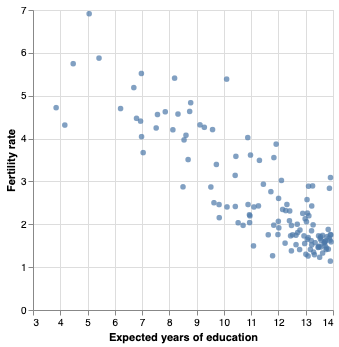

In [66]:
base = alt.Chart(data)
    
scatter_educ = base.mark_circle().encode( 
    x = alt.X("educ_expected_yrs_f:Q",
              scale = alt.Scale(zero = False),
              title = "Expected years of education"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_educ

#### Life Expectancy 

Here, we also see a strong negative, approximately linear association between fertility rate and women's life expectancy at birth. 

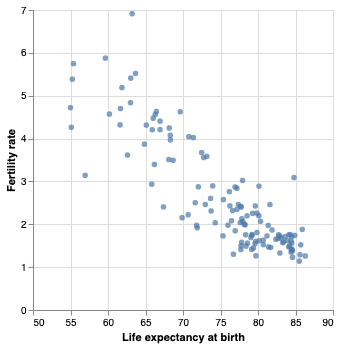

In [67]:
base = alt.Chart(data)
    
scatter_life = base.mark_circle().encode( 
    x = alt.X("life_birthf:Q",
              scale = alt.Scale(zero = False),
              title = "Life expectancy at birth"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_life

#### HDI 

The scatterplot shows a negative relationship between fertility rates and HDI. While the relationship is not perfectly linear, a linear approximation seems to provide a reasonable fit, suggesting that higher levels of human development are associated with lower fertility rates.


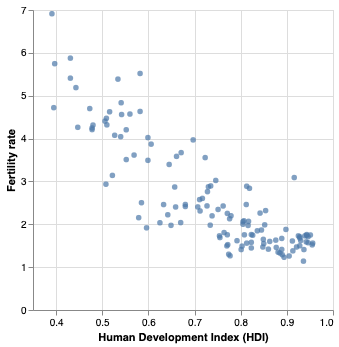

In [68]:
base = alt.Chart(data)
    
scatter_hdi = base.mark_circle().encode( 
    x = alt.X("hdi:Q",
              scale = alt.Scale(zero = False),
              title = "Human Development Index (HDI)"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_hdi

#### GDI 

We again observe a negative relationship, thought it does not appear strictly linear. This suggests that as GDI increases, fertility rates tend to decrease, but the pattern may be more complex than a simple linear trend.

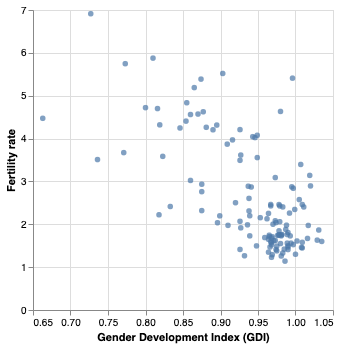

In [69]:
base = alt.Chart(data)
    
scatter_gdi = base.mark_circle().encode( 
    x = alt.X("gdi:Q",
              scale = alt.Scale(zero = False),
              title = "Gender Development Index (GDI)"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_gdi

#### GDP Per Capita 

With respect to GDP, we observe a relationship that resembles a multiplicative inverse, where fertility rates decrease as GDP per capita increases, approaching a lower limit of 1. 

The rate of decrease is steeper in the [0, 40,000] range and slows thereafter, suggesting that fertility rates drop more rapidly at lower income levels but stabilize as GDP reaches higher thresholds.

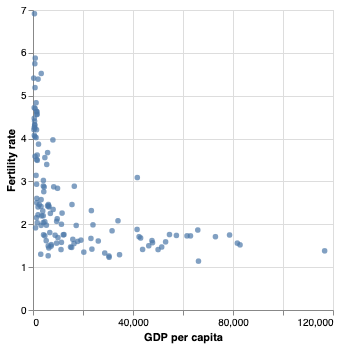

In [70]:
base = alt.Chart(data)
    
scatter_gdp = base.mark_circle().encode( 
    x = alt.X("gdp_percap:Q",
              scale = alt.Scale(zero = False),
              title = "GDP per capita"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_gdp

#### Immunization Rate

Once again, we observe a negative relationship, but the data is more scattered compared to the other variables. Immunization rates tend to cluster around the 90-100% range, with fertility rates showing a downward trend as immunization coverage increases.

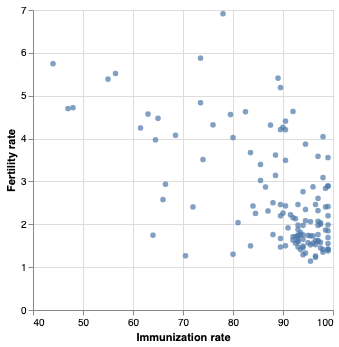

In [71]:
base = alt.Chart(data)
    
scatter_imz = base.mark_circle().encode( 
    x = alt.X("immunization:Q",
              scale = alt.Scale(zero = False),
              title = "Immunization rate"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_imz


These visualization validate the insights derived from our previous steps, confirming a strong linear negative relationship between fertility rates and education, life expectancy, HDI, and GDI. Meanwhile, GDP per capita and immunization rates show a more moderate, non-linear negative association.

## Multiple Regression Analysis

Now that we have a clearer understanding of how the variables influence fertility rates, we can proceed with modeling. In this section, we will define our model and fit it to the data, then assess its performance on multiple evaluation metrics. 

Next, we will run diagnostic tests to verify key assumptions, such as normality and homoscedasticity, and check for potential multicollinearity before addressing our research questions.

### Model Building

To improve interpretability, we will standardize the predictors. Since all our predictors are quantitative, the intercept will represent the average total fertility rate when all other variables are at their baseline values. 

It's important to note that standardizing the variables changes the scale of interpretation, meaning that the results will be expressed in terms of standard deviations from the global average. 

This approach allows for a clearer comparison of effect sizes, making it easier to understand how each predictor influences fertility rates relative to overall variability.

In [27]:
# create response vector
y = data.fertility_total

# create design matrix 
mat = data.iloc[:,1:7]
mat = (mat-mat.mean())/mat.std()   # normalize predictors 

# add intercept column (constant 1's)  
x = sm.tools.add_constant(mat)

# print first five rows of x
x.head()

,const,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
Country,,,,,,,
Afghanistan,1.0,-1.863465,-1.174374,-1.440808,-4.090610,-0.724618,-1.974439
Albania,1.0,0.727045,0.596805,0.370722,0.428830,-0.509795,0.656528
Algeria,1.0,0.285146,0.317620,0.076268,-1.199929,-0.560496,-0.262223
Angola,1.0,-1.791412,-1.469967,-0.973523,-0.568968,-0.599243,-2.684383
Argentina,1.0,0.670228,0.558729,0.690780,0.736974,-0.225086,0.113630


### Model Fitting 

We now fit the model to our data and evaluate its performance on key error metrics. These metrics provide insight into the model’s accuracy and generalizability, helping us determine its reliability for further analysis.

In [40]:
# fit model
mlr = sm.OLS(endog = y, exog = x)

# store result
rslt = mlr.fit()

# print key metrics
print(f"R-squared: {rslt.rsquared:.4f}")
print(f"Adjusted R-squared: {rslt.rsquared_adj:.4f}")
print(f"F-statistic: {rslt.fvalue:.2f} (p-value: {rslt.f_pvalue:.4g})")

R-squared: 0.8247
Adjusted R-squared: 0.8161
F-statistic: 95.69 (p-value: 9.771e-44)


Key metrics are summarized below:

* R-squared: 0.825, meaning the model explains 82.5% of the variation in fertility rates. 
* Adjusted R-squared: 0.812 (adjusted for the # of predictors); close to R-squared, indicating no overfitting.
* F-statistic: 95.69 (p < 0.0001) confirms the model's statistical significance.

The model appears to be a strong fit. 

### Model Diagnostics

Before finalizing the model, we must verify key regression assumptions to ensure its validity and reliability.

These include: 

* QQ plot: Validate normality assumptions for valid statistical inference. 

* Residual plots: Evaluate linearity and homoscedasticity (constant error variance).

* VIF: Check for multicollinearity (high correlation among predictors) to guide feature selection. 

#### Normality

In linear regression, residuals should follow a normal distribution to ensure valid statistical inference.

The Q-Q plot shows an approximately linear pattern, though the line is slightly flatter than the expected diagonal. This suggests heavier tails, indicating the presence of more extreme values. However, the overall pattern remains close to normal. The slight curvature also suggests mild skewness, though most points still align with the reference line.

These deviations are not severe, so the normality assumption remains reasonably valid for this model.

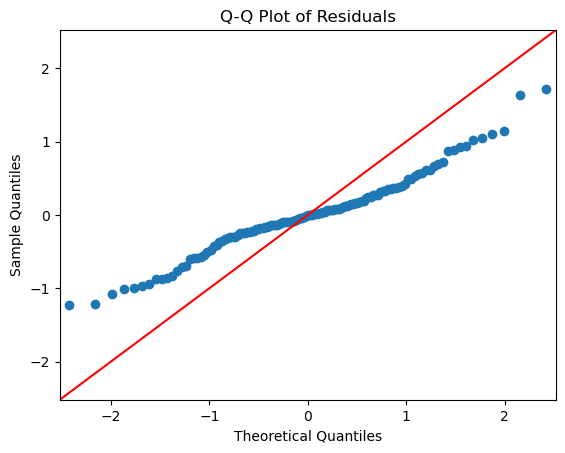

In [41]:
sm.qqplot(rslt.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

We'll run a Shapiro-Wilk test for formally test for normality.

In [42]:
from scipy import stats

stat, p_value = stats.shapiro(residuals)
print(f'Statistic: {stat}, p-value: {p_value}')

Statistic: 0.9732919931411743, p-value: 0.03499608114361763


The Shapiro-Wilk test checks if the residuals are normally distriubted. With a p-value of 0.035, there is slight evidence against normality, but the QQ-plot shows an approximately normal pattern in the Q-Q plot. This suggests that the normality assumption is not severely violated.

Minor departures typically do not significantly impact model performance, especially if other assumptions like homoscedasticity and linearity are met, which we will test in the next sections.

#### Residual plot

The residual plot shows random scatter with no apparent pattern, indicating homoscedasticity (constant error variance). A slight clustering around a fitted value of 1 may require further investigation but does not indicate a severe violation of assumptions.

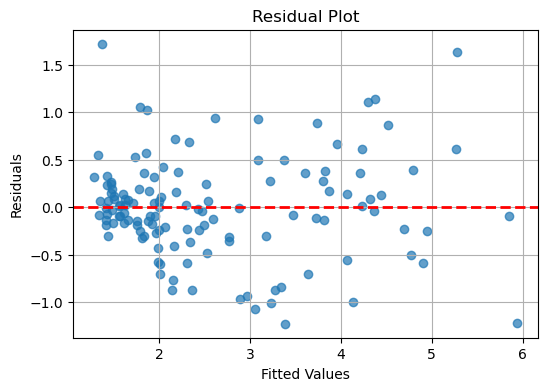

In [56]:
# create residual plot 
plt.figure(figsize=(6, 4))

plt.scatter(df['fitted_values'], df['residuals'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Fitted Values'); plt.ylabel('Residuals')

plt.grid(True); plt.show()

#### Multicollinearity

High multicollinearity among predictors can lead to unstable coefficient estimates and hinder model interpretability. This may be an issue in our dataset, as indicated by our correlation analysis and PCA results.

The Variance Inflation Factor (VIF) quantifies multicollinearity, with an upper threshold of 5-10. A high VIF can inflate the significance of the model, distorting the true effect of predictors.


In [59]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# compute the VIF for each feature in the design matrix x
vif_data = pd.DataFrame()
vif_data['Feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

# display the VIF values
print(vif_data)

               Feature        VIF
0                const   1.000000
1  educ_expected_yrs_f   6.084975
2          life_birthf   8.242011
3                  hdi  15.629728
4                  gdi   2.111264
5           gdp_percap   2.398091
6         immunization   1.863205


We find that `hdi`, `life_birthf`, and `educ_expected_yes_f have high VIF scores ranging from 6 to 15, while other predictors have moderate to low VIFs. 

HDI is a composite measure of health, education, and standard of living, so it makes sense for it to be correlated with other socioeconomic indicators such as education and life expectancy. However, these high VIF suggests that these issues must be addressed. 

##### How should we proceed?

First, let's summarize our findings:

* HDI, education, and life expectancy are highly correlated (0.83-0.93), suggesting that these variables may be capturing similar underlying information.

* These feautures have high VIF scores that suggest problematic multicollinearity. 

Next steps: 
* Remove HDI: One option is to remove `hdi` from the model. This approach is non-optimal as it can lead to information loss. 

* Regularization: Apply Ridge or Lasso regression techniques to address multicollinearity, allowing the model to work even when predictors are correlated.

We will proceed with option 2, then address our research questions based on the model results.

### Model Refinement

We will implement a Lasso regression model to analyze fertility rates, addressing multicollinearity by shrinking less important features to zero. Lasso performs both regularization and feature selection, helping to identify the most influential predictors.

In [97]:
from sklearn.linear_model import Lasso
import numpy as np

# normalize predictors
X = data.iloc[:,1:7]
X = (X - X.mean()) / X.std()  # no need to manually add constant column 

# fit Lasso model with normalized predictors 
lasso = Lasso(alpha=0.1)
lasso.fit(X, y)

# store evaluation metrics   
lasso_results = {
    "Intercept": lasso.intercept_,
    "Coefficients": lasso.coef_,
    "Mean Squared Error": np.mean((y - lasso.predict(X)) ** 2),
    "R-squared": lasso.score(X, y)
}

# print key metrics
print(f"Intercept: {lasso_results['Intercept']:.4f}")
for var, coef in zip(X.columns, lasso_results['Coefficients']):
    print(f"{var}: {coef:.4f}")
print(f"Mean Squared Error: {lasso_results['Mean Squared Error']:.4f}")
print(f"R-squared: {lasso_results['R-squared']:.4f}")

Intercept: 2.6042
educ_expected_yrs_f: -0.4730
life_birthf: -0.5193
hdi: -0.0511
gdi: -0.0542
gdp_percap: 0.0000
immunization: -0.0000
Mean Squared Error: 0.3004
R-squared: 0.8104


As we see from the above results, the coefficients for `gdp_percap` and `immunization` have been shrunk to 0, confirming our previous suspicions (from correlation analysis) that these are unimportant factors in explaining fertility rates. 

Key metrics are summarized below: 

 * R-squared: 0.8104, similar performance as our OLS model. 
 * MSE: 0.3004, indicating that the model captures relationships reasonably well with room for improvement.

Next, we turn to address our research questions based on these evaluation results. 

## Research questions 

In this section, we'll tackle our initial research questions. Namely:

* Which factors most predict a country’s fertility rate?
* How do upward mobility, economic prosperity, and child well-being impact fertility rates?
* Which of these explanations are the most probable?

#### Which factors most predict a country’s fertility rate? 

The results of our Lasso regression model indicates that education, life expectancy, hdi, and gdi and important predictors, while immunization and GDP per capita are less important. 

These findings aligns with insights extracted from our PCA analysis: a "developmental" axis where higher development and education levels are associated with lower fertility rates.  

In [98]:
for var, coef in zip(X.columns, lasso_results['Coefficients']):
    print(f"{var}: {coef:.4f}")

educ_expected_yrs_f: -0.4730
life_birthf: -0.5193
hdi: -0.0511
gdi: -0.0542
gdp_percap: 0.0000
immunization: -0.0000


#### How do upward mobility, economic prosperity, and child well-being impact fertility rates?


Upward mobility (proxied by education and hdi): The negative coefficients for education (-0.47) and HDI (-0.051) suggest that higher development and education are associated with lower fertility rates. This reflects the trend that better education and opportunities for upward mobility tend to result in smaller family sizes.

Economic prosperity: Surprisingly, GDP per capita has a coefficient of 0 in our model. This suggests that other factors like income distribution or social safety nets may be more relevant for fertility, rather than GDP alone.

Child well-being (proxied by life expectancy): The negative relationship between life expectancy (-0.5193) and fertility rates suggests that better health conditions lead to lower fertility rates. This aligns with the idea that countries with better child well-being tend to have lower fertility rates as parents invest more in fewer children with higher quality of life.


#### Which explanations are most probable?


The most probable explanations are education and development. GDP per capita has little impact, while life expectancy supports the child well-being argument.

## Conclusion

In this project, we explored the declining fertility rates across select countries in 2018. Given the small dataset and a large number of unrelated variables, we tidied the data, conducted principal component analysis (PCA), and performed exploratory analysis to identify patterns. We then fit a supervised model and evaluated the results. Our analysis revealed that both improvements in well-being and increasing social mobility for women are negatively associated with fertility rates.

Due to time constraints and the complexity of the research questions, we acknowledge the limitations of our model. The fertility rate of a country is highly variable, and our model's susceptibility to noise prevented us from fully capturing all influencing factors. Additionally, focusing solely on 2018 data restricted our scope. Moving forward, future analyses could include additional variables, address missing data, and explore more robust modeling approaches. More complex models and the consideration of time-series analysis could help account for temporal variations and autocorrelation, offering a clearer picture of fertility trends.